<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_051_catboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 51/365 — CatBoost
## How can Gradient Boosting handle categorical features more naturally?

Yesterday we explored **LightGBM**.

Today we move to another important Gradient Boosting library:

**CatBoost — Categorical Boosting**

CatBoost was designed with a major practical challenge in mind:

**How do we work effectively with categorical features without manually creating huge one-hot encoded matrices?**

It can work directly with categorical columns, which is useful for enterprise datasets containing fields such as city, product type, device type, customer segment, or channel.


In [8]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

# Install CatBoost if it's not already installed
try:
    from catboost import CatBoostClassifier
except ImportError:
    !pip install catboost
    from catboost import CatBoostClassifier


## 1. Build an offline-friendly mixed-type dataset

We create a synthetic customer-risk dataset containing both numerical and categorical features.


In [9]:
rng=np.random.default_rng(42)
n=1500

df=pd.DataFrame({
    "age":rng.integers(21,70,n),
    "income":rng.normal(70000,25000,n).clip(15000,180000),
    "transactions_30d":rng.integers(1,80,n),
    "city":rng.choice(["Delhi","Mumbai","Bengaluru","Dehradun","Pune"],n),
    "device":rng.choice(["Android","iOS","Web"],n),
    "segment":rng.choice(["Standard","Premium","Business"],n)
})

risk_score=(
    (df["transactions_30d"]>55).astype(int)*1.2
    +(df["income"]<40000).astype(int)*0.8
    +(df["device"]=="Web").astype(int)*0.5
    +(df["segment"]=="Standard").astype(int)*0.4
    +rng.normal(0,0.6,n)
)

df["high_risk"]=(risk_score>1.3).astype(int)

display(df.head())
print(df["high_risk"].value_counts(normalize=True).round(3))


,age,income,transactions_30d,city,device,segment,high_risk
0,25,67595.526577,48,Mumbai,iOS,Business,0
1,58,98200.471434,50,Mumbai,Web,Standard,0
2,53,15000.000000,74,Mumbai,iOS,Premium,0
3,42,32584.032752,49,Dehradun,Web,Premium,1
4,42,46927.838953,36,Bengaluru,iOS,Business,0


high_risk
0    0.72
1    0.28
Name: proportion, dtype: float64


## 2. Split the data and identify categorical columns


In [10]:
X=df.drop(columns="high_risk")
y=df["high_risk"]

categorical_features=["city","device","segment"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

print("Categorical columns:",categorical_features)


Categorical columns: ['city', 'device', 'segment']


## 3. Train CatBoost directly on raw categorical columns

Notice that we do **not** manually call `OneHotEncoder`.


In [11]:
start=time.perf_counter()

model=CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="Logloss",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

training_time=time.perf_counter()-start

pred=model.predict(X_test).astype(int).ravel()
prob=model.predict_proba(X_test)

accuracy=accuracy_score(y_test,pred)
loss=log_loss(y_test,prob)

print("Test Accuracy:",round(accuracy,3))
print("Test Log Loss:",round(loss,3))
print("Training Time:",round(training_time,4),"seconds")


Test Accuracy: 0.824
Test Log Loss: 0.402
Training Time: 0.786 seconds


## 4. Feature importance


,Feature,Importance
2,transactions_30d,37.625
1,income,18.502
5,segment,13.527
3,city,11.246
4,device,10.644
0,age,8.456


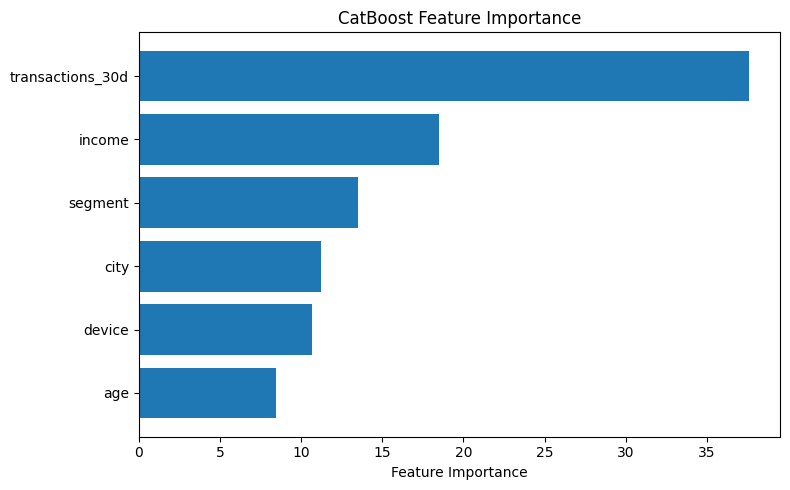

In [12]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.get_feature_importance()
}).sort_values("Importance",ascending=False)

display(importance.round(3))

plot_data=importance.sort_values("Importance")

plt.figure(figsize=(8,5))
plt.barh(plot_data["Feature"],plot_data["Importance"])
plt.xlabel("Feature Importance")
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()


## 5. Why categorical features are tricky

If we convert:

`Delhi=1, Mumbai=2, Pune=3`

we create a fake numerical order.

One-hot encoding avoids that, but high-cardinality columns can create very wide matrices.

CatBoost uses specialized statistics for categorical variables during training instead of requiring us to manually build those large one-hot matrices.


## 6. Ordered target statistics — intuition

A naive approach would be to replace each category with its average target value.

But if the current row's target contributes to that encoding, information can leak.

CatBoost uses an **ordered** approach so the encoding for an observation does not simply use that observation's own target.

This helps reduce target leakage and prediction shift.


## 7. Enterprise intuition

Imagine a fraud or customer-risk dataset containing:

- merchant category
- city
- payment channel
- browser
- device type
- customer segment
- employer type

These are categorical features.

A traditional workflow may look like:

`Raw data → Encoding → Large transformed matrix → Model`

CatBoost can often simplify this to:

`Raw mixed-type data → CatBoost`

That can make experimentation and production pipelines easier to manage.


## 8. XGBoost vs LightGBM vs CatBoost

All three belong to the Gradient Boosting family.

### XGBoost
- optimized boosting
- strong regularization
- strong general-purpose tabular performance

### LightGBM
- histogram-based learning
- leaf-wise growth
- efficient large-scale training

### CatBoost
- strong categorical feature handling
- ordered statistics
- convenient mixed-type tabular workflows

There is no universal winner. Validation still decides.


## What does this experiment teach?

- CatBoost is a Gradient Boosting library.
- It can accept categorical columns directly.
- We do not always need to manually one-hot encode categorical data.
- Ordered statistics help reduce leakage-related problems from naive target encoding.
- Feature importance helps inspection, but it does not prove causality.
- XGBoost, LightGBM and CatBoost solve similar problem families with different engineering choices.

> **A large part of real-world ML is not only choosing the algorithm — it is representing business data correctly before the algorithm learns from it.**


## References

- https://catboost.ai/en/docs/
- https://catboost.ai/en/docs/features/categorical-features
- https://arxiv.org/abs/1706.09516
- https://catboost.ai/en/docs/concepts/python-reference_catboostclassifier
